## Resampling to adjust (teff, mag, rad, prot) distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
from plotutils import *
from resample import *
import matplotlib.lines as mlines

import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='Times New Roman')
plt.rcParams["figure.figsize"] = (10,6)
from matplotlib import rc
rc('text', usetex=True)
import warnings
warnings.filterwarnings("ignore")

In [28]:
lmag = r'\textit{Kepler} magnitude $K_p$'
llogr = '$\log_{10} R$ (ppm)'
figdir = 'rdist'
figdir = 'plots_dist'

In [3]:
def sample_dkic_pi(dkic):
    piD = dkic.pdet
    idx = np.random.choice(np.arange(len(dkic)), size=len(dkic), p=piD/np.sum(piD))
    dkic_pi = dkic.iloc[idx].reset_index(drop=True)
    return dkic_pi

def get_resampled_kic(dkic_pi, dkoi, teff_bins):
    dkic_smp = sample_near_dkoi(dkic_pi, dkoi, teff_bins, rad_col='lograd')
    return dkic_smp

In [4]:
datadir = '../data_m15/'
dkoi = pd.read_csv(datadir+"m15_koi.csv")
dkic = pd.read_csv("../pdet/m15_kic_w_pdet_TR.csv")

dkicrad = pd.read_csv("../data/DR2PapTable1.txt", delimiter='&')
dkoi = pd.merge(dkoi, dkicrad[['KIC', 'rad']], on='KIC')

dkic['logp'] = np.log10(dkic.Prot)
dkoi['logp'] = np.log10(dkoi.Prot)
dkic['lograd'] = np.log10(dkic.rad)
dkoi['lograd'] = np.log10(dkoi.rad)

### single resampling

In [5]:
dkic_pi = sample_dkic_pi(dkic)

In [6]:
teff_bins = np.arange(3500, 6501, 100)
dkic_smp = get_resampled_kic(dkic_pi, dkoi, teff_bins=teff_bins)

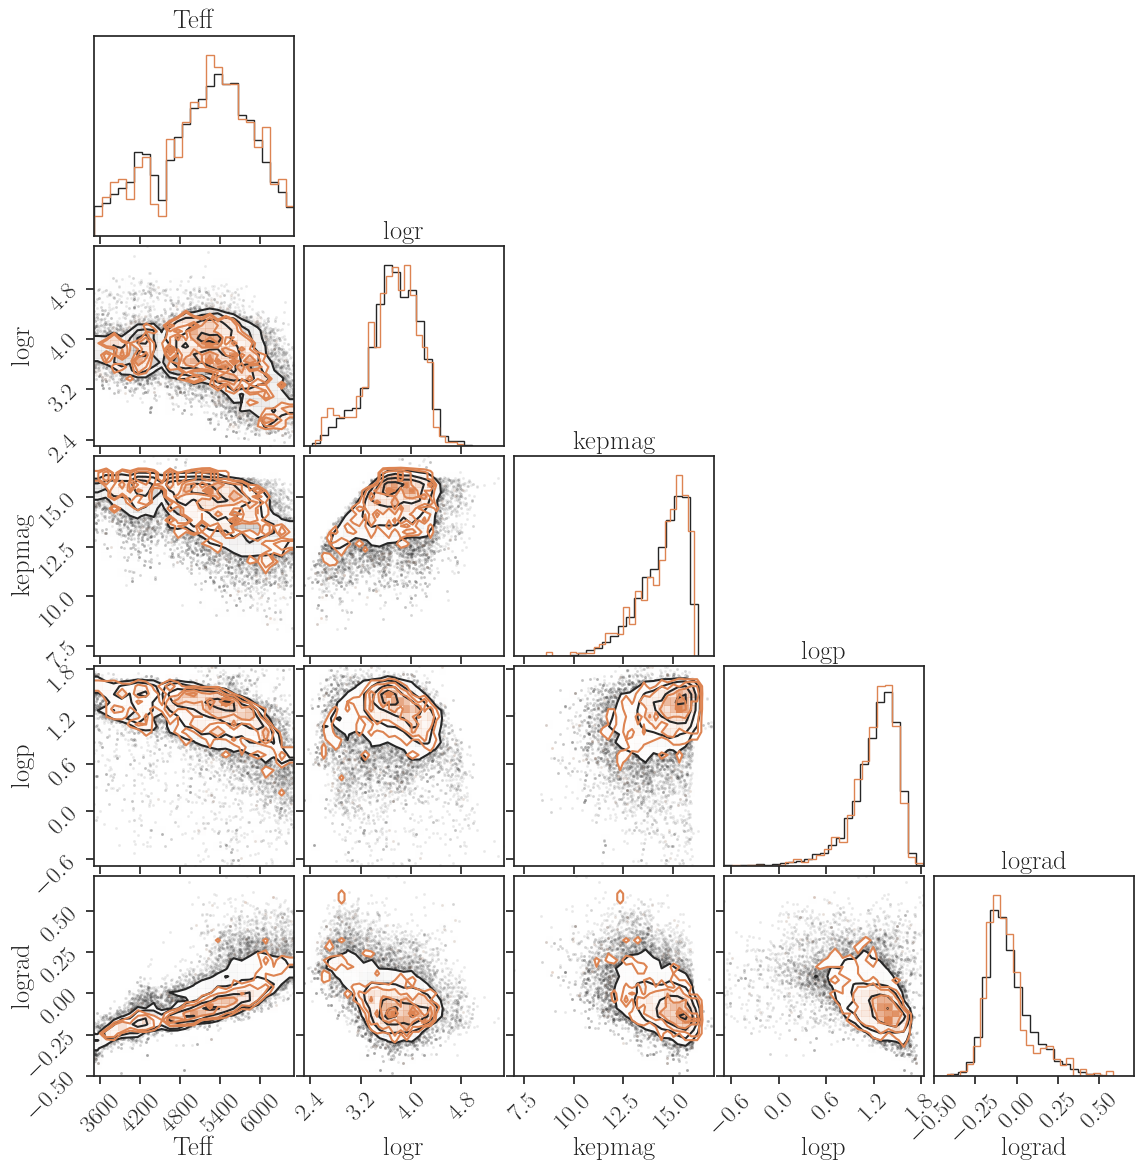

In [7]:
# check
keys = ['Teff', 'logr', 'kepmag', 'logp', 'lograd']
fig = corner.corner(np.array(dkic_pi[keys]), labels=keys, show_titles=True, title_fmt=None, hist_kwargs={'density': True}, bins=25)
_ = corner.corner(np.array(dkic_smp[keys]), labels=keys, show_titles=True, title_fmt=None, hist_kwargs={'density': True}, color='C1', fig=fig, bins=25)

### repeated resampling

In [8]:
dkic_rs_list = []
for i in range(200):
    dkic_pi = sample_dkic_pi(dkic)
    dkic_rs_list.append(get_resampled_kic(dkic_pi, dkoi, teff_bins))

In [9]:
dkic_rs = pd.concat(
    [d.assign(rs_id=i) for i, d in enumerate(dkic_rs_list)],
    ignore_index=True,
)

dkic_rs_corner = dkic_rs.sample(
    n=min(len(dkic_rs), 50000),
    random_state=0,
).reset_index(drop=True)

dkic_rs.shape, dkic_rs['rs_id'].nunique(), dkic_rs_corner.shape

((176000, 41), 200, (50000, 41))

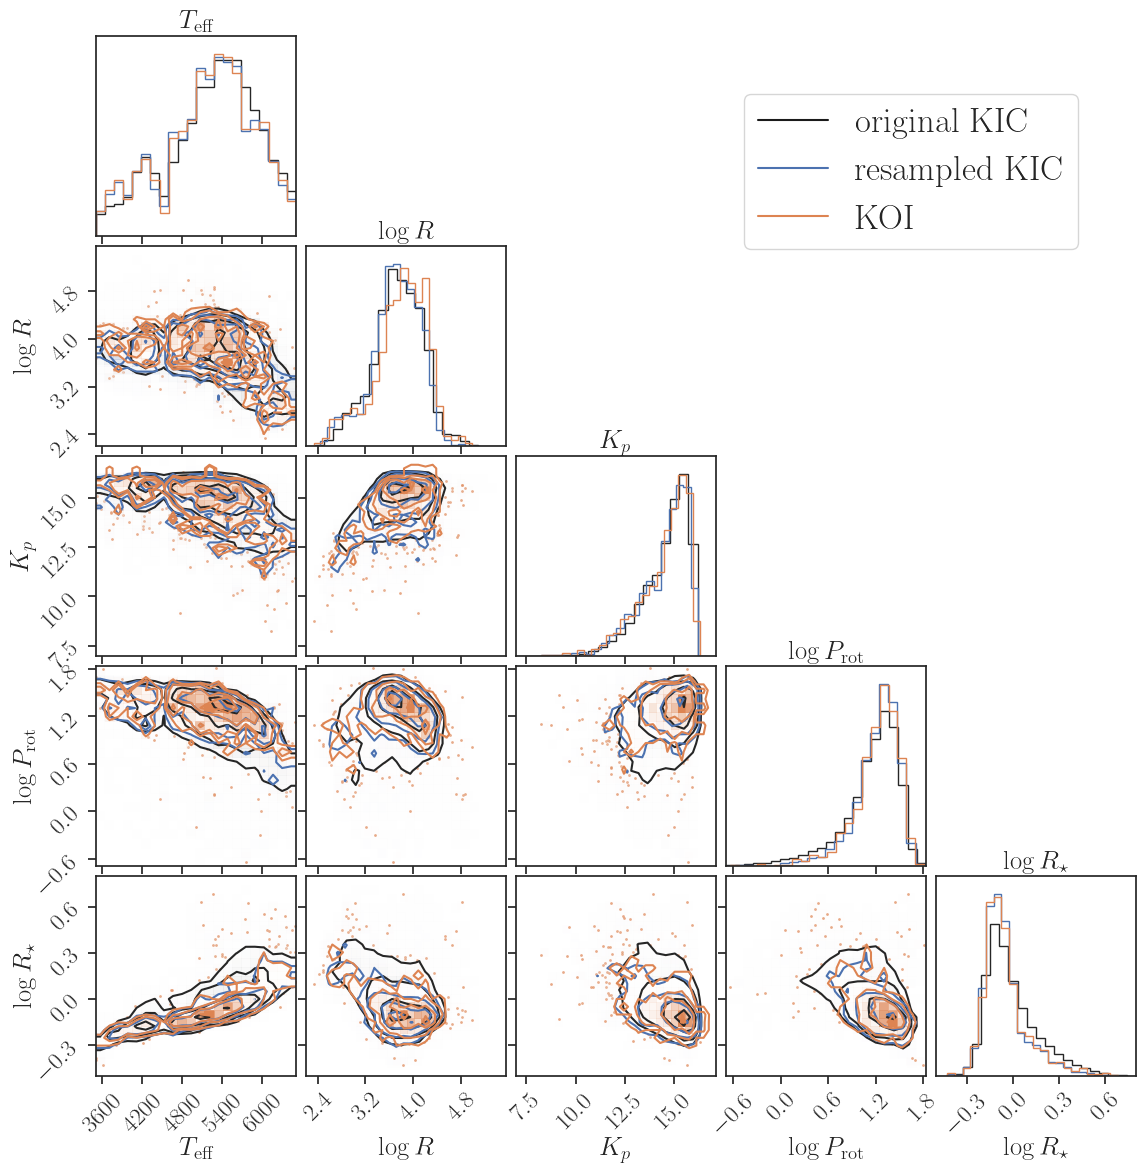

In [41]:
keys = ['Teff', 'logr', 'kepmag', 'logp', 'lograd']
labels = ['$T_\mathrm{eff}$', '$\log R$', '$K_p$', '$\log P_\mathrm{rot}$', '$\log R_\star$']
plot_range = [1., [2.2, 5.55], 1., 1., [-0.5, 0.8]]
nbin = 22

fig = corner.corner(
    np.array(dkic[keys]),
    labels=labels,
    show_titles=True,
    title_fmt=None,
    hist_kwargs={'density': True},
    bins=nbin,
    plot_datapoints=False,
    range=plot_range
)
_ = corner.corner(
    np.array(dkic_rs_corner[keys]),
    labels=labels,
    show_titles=True,
    title_fmt=None,
    hist_kwargs={'density': True},
    color='C0',
    fig=fig,
    bins=nbin,
    plot_datapoints=False,

)

_ = corner.corner(
    np.array(dkoi[keys]),
    labels=labels,
    show_titles=True,
    title_fmt=None,
    hist_kwargs={'density': True},
    color='C1',
    fig=fig,
    data_kwargs={'alpha': 0.7},
    bins=nbin,
)

handles = [
    mlines.Line2D([], [], color="k", label="original KIC"),
    mlines.Line2D([], [], color="C0", label="resampled KIC"),
    mlines.Line2D([], [], color="C1", label="KOI"),
]
plt.legend(handles=handles, bbox_to_anchor=(0.8, len(keys)), fontsize=25)
plt.savefig(figdir+'/resample_corner.png', dpi=200, bbox_inches='tight')

### 1D dists

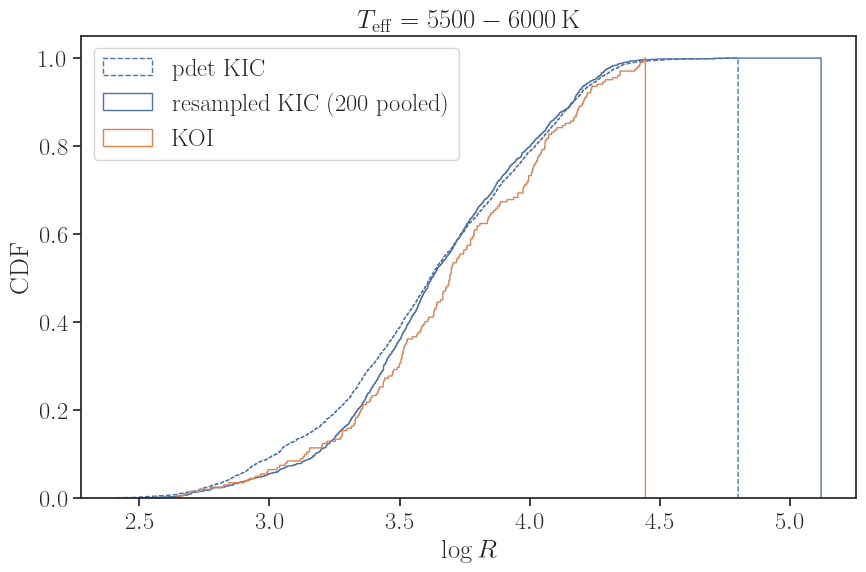

In [39]:
query = 'Teff < 6000 and Teff > 5500'
key = 'logr'
cumulative, bins = True, 1000
#cumulative, bins = False, 50
plt.hist(dkic_pi.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='pdet KIC', color='C0', ls='dashed')
plt.hist(dkic_rs.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='resampled KIC (200 pooled)',
         color='C0')
plt.hist(dkoi.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='KOI', color='C1')
plt.legend(loc='best')
plt.xlabel('$\\log R$')
plt.ylabel('CDF')
plt.title('$T_\mathrm{eff}=5500-6000\,\mathrm{K}$')
plt.savefig(figdir+'/t5500-6000.png', dpi=200, bbox_inches='tight')

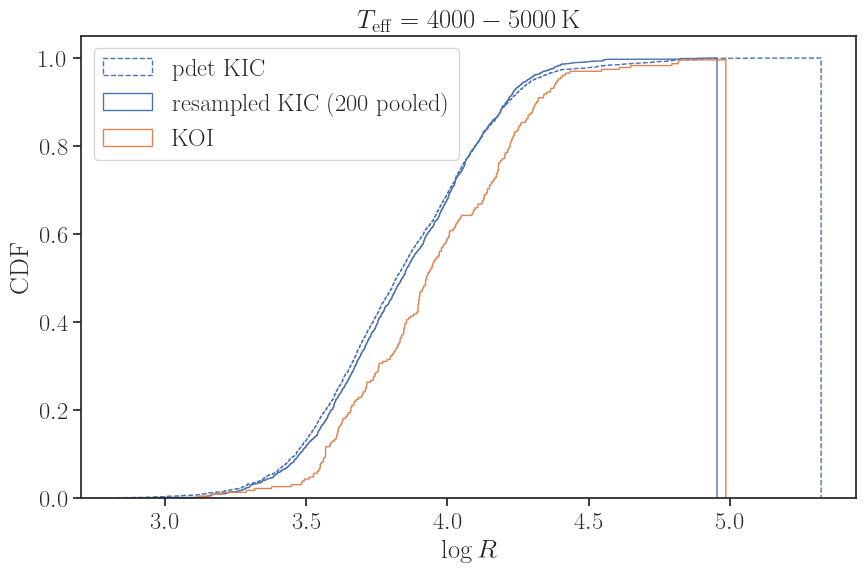

In [40]:
query = 'Teff < 5000 and Teff > 4000'
key = 'logr'
cumulative, bins = True, 1000
#cumulative, bins = False, 50
plt.hist(dkic_pi.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='pdet KIC', color='C0', ls='dashed')
plt.hist(dkic_rs.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='resampled KIC (200 pooled)',
         color='C0')
plt.hist(dkoi.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label='KOI', color='C1')
plt.legend(loc='best')
plt.xlabel('$\\log R$')
plt.ylabel('CDF')
plt.title('$T_\mathrm{eff}=4000-5000\,\mathrm{K}$')
plt.savefig(figdir+'/t4000-5000.png', dpi=200, bbox_inches='tight')

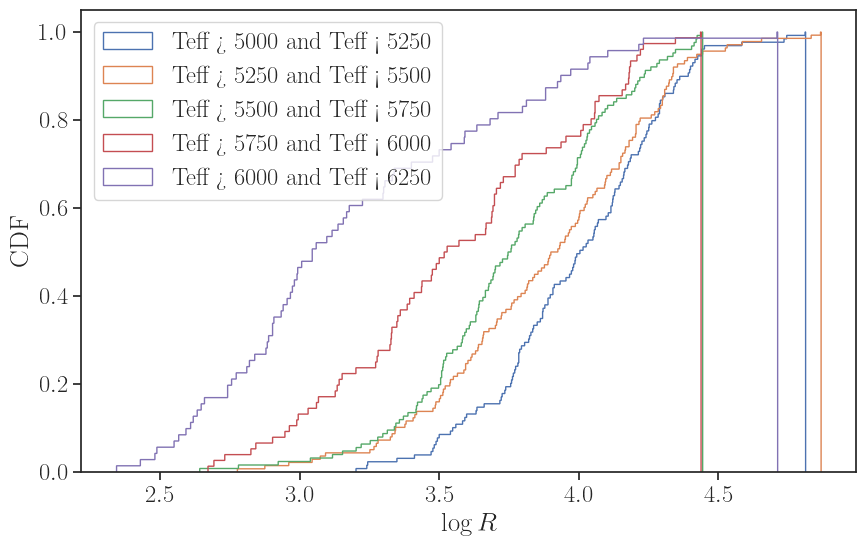

In [34]:
key = 'logr'
cumulative, bins = True, 1000
for t in [5000, 5250, 5500, 5750, 6000]:
    query = f'Teff > {t} and Teff < {t+250}'
    plt.hist(dkoi.query(query)[key], cumulative=cumulative, density=True, histtype='step', lw=1, bins=bins, label=query)
plt.legend(loc='best')
plt.xlabel('$\\log R$')
plt.ylabel('CDF');

### eCDF comparisons

In [11]:
def _plot_ecdf_line(ax, x, mode='cdf', **plot_kwargs):
    if mode not in ('cdf', 'survival'):
        raise ValueError("mode must be 'cdf' or 'survival'")

    x = pd.Series(x).dropna().to_numpy(float)
    if len(x) == 0:
        return 0

    x = np.sort(x)
    y = np.arange(1, len(x) + 1, dtype=float) / len(x)
    if mode == 'survival':
        y = 1.0 - y

    ax.step(x, y, where='post', **plot_kwargs)
    return len(x)


def plot_pooled_resample_ecdf_by_teffbin(
    dkic_pi,
    dkoi,
    dkic_rs=None,
    *,
    key='logr',
    xlabel=None,
    teff_bins=np.arange(3500, 6501, 500),
    mode='cdf',
    show_kic=True,
    show_resampled=True,
    show_koi=True,
    label_kic='pdet KIC',
    label_resampled='resampled KIC (pooled)',
    label_koi='KOI',
    colors=('k', 'C0', 'C1'),
    linestyles=('-', 'dashed', 'dotted'),
    linewidths=(1., 2., 2.),
    nrows=2,
    ncols=3,
    figsize=(12, 7),
    sharex=True,
    sharey=True,
    invert_x=False,
    xlim=None,
    ylim=(0, 1),
    show_N=True,
    title_fmt=r'${left:.0f}-{right:.0f}\,\mathrm{{K}}$',
    legend_1st=False,
):
    if show_resampled and dkic_rs is None:
        raise ValueError('dkic_rs is required when show_resampled=True')

    datasets = []
    if show_kic:
        datasets.append((dkic_pi, label_kic, colors[0], linestyles[0], linewidths[0]))
    if show_resampled:
        datasets.append((dkic_rs, label_resampled, colors[1], linestyles[1], linewidths[1]))
    if show_koi:
        datasets.append((dkoi, label_koi, colors[2], linestyles[2], linewidths[2]))
    if len(datasets) == 0:
        raise ValueError('At least one of show_kic, show_resampled, show_koi must be True')

    for df, label, _, _, _ in datasets:
        missing = {'Teff', key} - set(df.columns)
        if missing:
            raise KeyError(f'{label} is missing columns: {sorted(missing)}')

    teff_bins = np.asarray(teff_bins, dtype=float)
    intervals = list(zip(teff_bins[:-1], teff_bins[1:]))
    if nrows * ncols < len(intervals):
        raise ValueError('nrows * ncols must be at least len(teff_bins) - 1')

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
    )
    axes = np.asarray(axes).ravel()

    for i, (ax, (left, right)) in enumerate(zip(axes, intervals)):
        n_text = []
        for df, label, color, linestyle, linewidth in datasets:
            d = df.dropna(subset=['Teff', key])
            lower = d['Teff'] >= left
            upper = d['Teff'] <= right if i == len(intervals) - 1 else d['Teff'] < right
            g = d.loc[lower & upper]
            n = _plot_ecdf_line(
                ax,
                g[key],
                mode=mode,
                color=color,
                ls=linestyle,
                lw=linewidth,
                label=label,
            )
            n_text.append(f'{label}: N={n}')

        ax.set_title(title_fmt.format(left=left, right=right))
        if invert_x:
            ax.invert_xaxis()
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        if show_N:
            ax.text(
                0.03,
                0.04,
                '\n'.join(n_text),
                transform=ax.transAxes,
                fontsize=10,
                va='bottom',
            )

    for ax in axes[len(intervals):]:
        ax.set_visible(False)

    if xlabel is None:
        xlabel = key
    fig.supxlabel(xlabel, y=0.0)
    fig.supylabel('Cumulative fraction' if mode == 'cdf' else 'Survival fraction (1-CDF)', x=0.0)
    if legend_1st:
        axes[0].legend(frameon=False, fontsize=16, loc='upper left')
    else:
        axes[-1].legend(frameon=False, fontsize=16, loc='lower right')
    plt.tight_layout(pad=0.5)
    return fig, axes

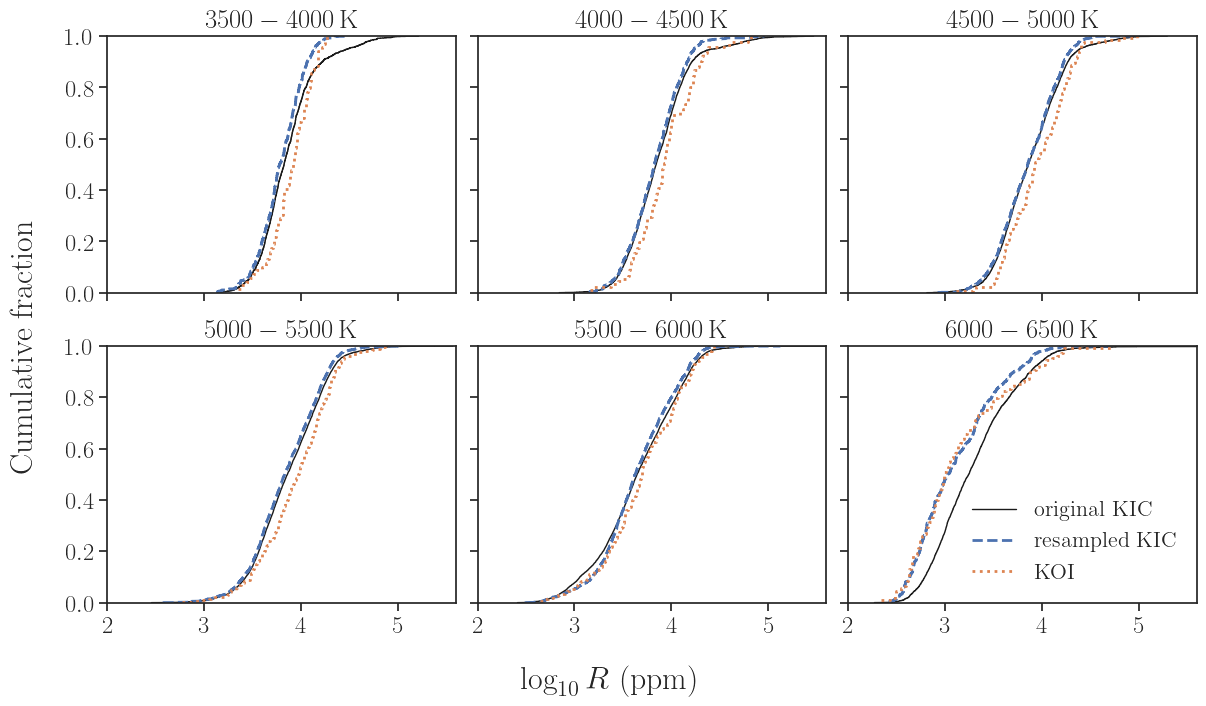

In [29]:
fig, axes = plot_pooled_resample_ecdf_by_teffbin(
    dkic,
    dkoi,
    dkic_rs,
    xlim=(2., 5.6),
    key='logr',
    xlabel=llogr,
    label_kic='original KIC',
    label_resampled='resampled KIC',
    label_koi='KOI',
    show_resampled=True,
    show_N=False,
)
plt.savefig(figdir + '/ecdf_by_teff_logr.png', dpi=200, bbox_inches='tight')

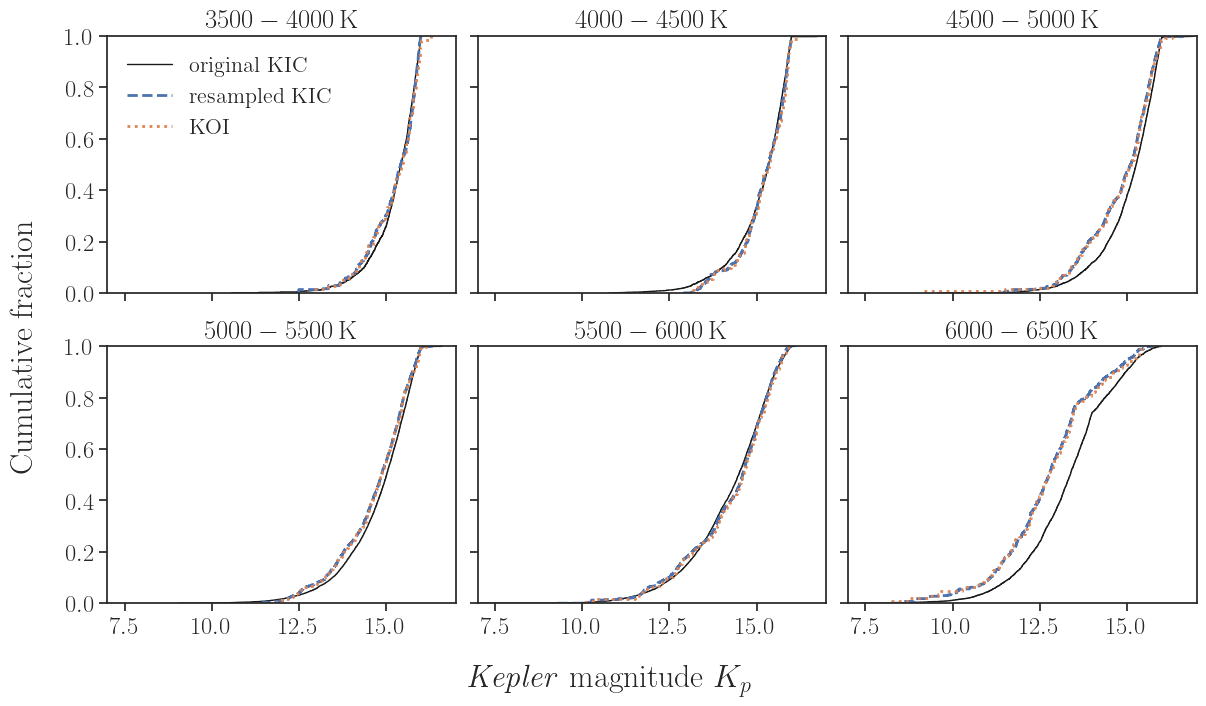

In [42]:
fig, axes = plot_pooled_resample_ecdf_by_teffbin(
    dkic,
    dkoi,
    dkic_rs,
    key='kepmag',
    xlabel=lmag,
    label_kic='original KIC',
    label_resampled='resampled KIC',
    label_koi='KOI',
    show_resampled=True,
    invert_x=True,
    show_N=False,
    xlim=(7, 17),
    legend_1st=True
)
plt.savefig(figdir + '/ecdf_by_teff_kepmag.png', dpi=200, bbox_inches='tight')

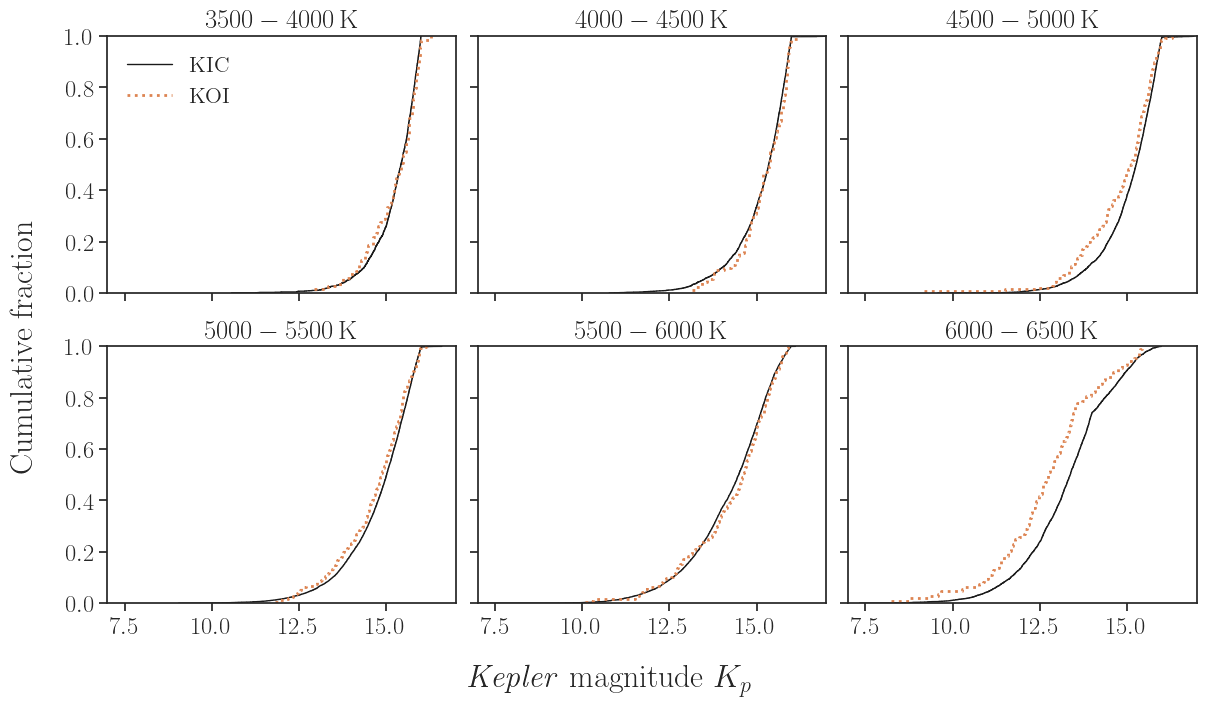

In [44]:
fig, axes = plot_pooled_resample_ecdf_by_teffbin(
    dkic,
    dkoi,
    dkic_rs,
    key='kepmag',
    xlabel=lmag,
    label_kic='KIC',
    label_resampled='resampled KIC',
    label_koi='KOI',
    show_resampled=False,
    invert_x=True,
    show_N=False,
    xlim=(7, 17),
    legend_1st=True
)
plt.savefig(figdir + '/ecdf_by_teff_kepmag_no-resample.png', dpi=200, bbox_inches='tight')

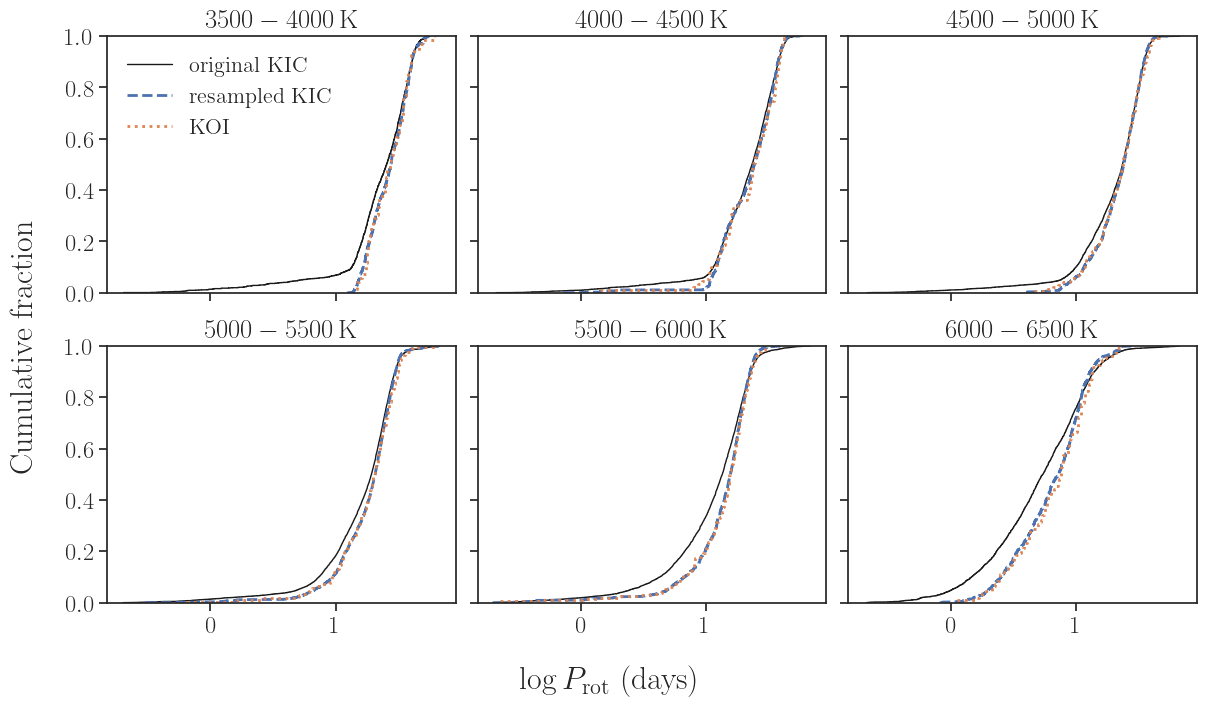

In [20]:
fig, axes = plot_pooled_resample_ecdf_by_teffbin(
    dkic,
    dkoi,
    dkic_rs,
    key='logp',
    xlabel='$\log P_\mathrm{rot}$ (days)',
    label_kic='original KIC',
    label_resampled='resampled KIC',
    label_koi='KOI',
    show_resampled=True,
    invert_x=True,
    show_N=False,
    #xlim=(7, 17),
    legend_1st=True
)
plt.savefig(figdir + '/ecdf_by_teff_logp.png', dpi=200, bbox_inches='tight')

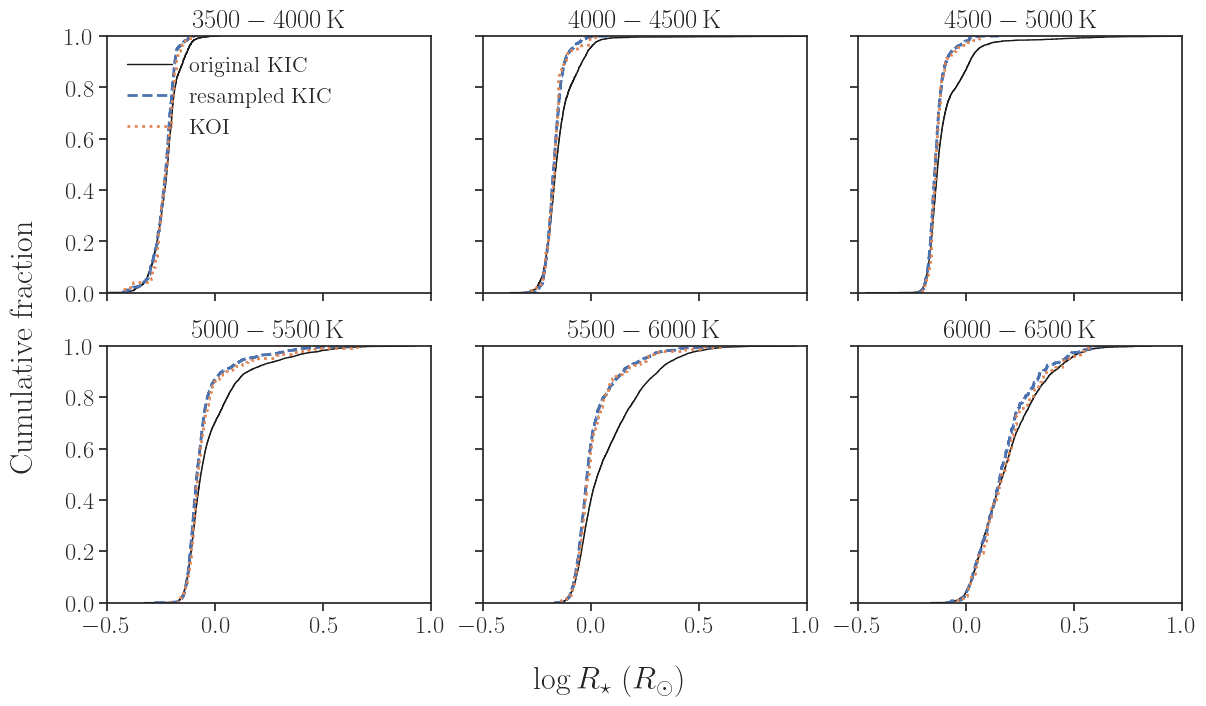

In [21]:
fig, axes = plot_pooled_resample_ecdf_by_teffbin(
    dkic,
    dkoi,
    dkic_rs,
    key='lograd',
    xlabel='$\log R_\star$ ($R_\odot$)',
    label_kic='original KIC',
    label_resampled='resampled KIC',
    label_koi='KOI',
    show_resampled=True,
    invert_x=True,
    show_N=False,
    xlim=(-0.5, 1.0),
    legend_1st=True
)
plt.savefig(figdir + '/ecdf_by_teff_logradr.png', dpi=200, bbox_inches='tight')